# Project 1: Comparing Financial Performance Across Major U.S. Banks (2005–2024)

**INTRODUCTION:**

In this project, I explore how Bank of America’s financial performance compares with JPMorgan Chase, Citigroup, and Wells Fargo from 2005 through 2024. My main question is: How do profitability, efficiency, and equity financing differ across these banks over time?

I use financial ratios and annual revenue and net income to compare both relative performance and business scale. The charts highlight selected economic periods so that changes can be examined in context. This is an exploratory comparison rather than a forecasting or clustering model.

**WHAT IS EXPLORATORY FINANCIAL ANALYSIS?**

Exploratory financial analysis uses financial measures and visualizations to identify patterns, differences, and questions worth investigating. A bank with more revenue is not necessarily more profitable relative to its assets or equity, so I compare several measures instead of relying on a single ranking.

Line charts are useful here because they show the timing and direction of changes. They help identify whether banks move together or diverge, but they do not establish what caused those changes.

**THE DATA:**

The analysis covers Bank of America, Citigroup, Wells Fargo, and JPMorgan Chase over 20 years. The supplied combined dataset contains 80 bank-year records. The original code reads one CSV per bank, adds a bank identifier, and combines the files into one table.

For this presentation, the charts were rendered from the combined dataset supplied with the project, separated into the four inputs expected by the original code. The figures reflect that dataset; the underlying filings and revenue definitions have not been independently reconciled here.

**FEATURES:**

**ROE (Return on Equity):** net income relative to shareholder equity.

**ROA (Return on Assets):** net income relative to assets.

**Profit Margin:** net income relative to reported revenue.

**Asset Turnover:** reported revenue relative to assets.

**Equity-to-Assets:** the share of assets financed by shareholder equity; this is not a regulatory capital ratio.

**Total Revenue:** the dataset’s reported annual revenue, labeled in USD millions by the code.

**Net Income:** annual earnings, labeled in USD millions by the code.

Ratios are displayed as decimals, so 0.10 represents 10%. Consistent revenue definitions and ratio denominators are important when comparing banks.

**DATA UNDERSTANDING / VISUALIZATION:**

I created seven line charts, with a separate line for each bank. Each chart follows one measure across the full period, allowing changes within a bank and differences between banks to be viewed together.

The shaded windows mark 2008–2009, 2020, and 2022–2024 for comparison with the financial crisis, pandemic, and recent rate environment. These windows provide context rather than a causal test or precise dating of each event.

**PREPROCESSING THE DATA:**

I used pandas to read the four CSV files, attach a bank label, and concatenate them into one table. The code converts Year and ROE to numeric values, coercing unconvertible entries to missing values. It then sorts observations by year within each bank before plotting.

The code checks whether Profit Margin, Asset Turnover, and Equity_to_Assets exist before drawing their lines. It does not explicitly convert all remaining measures, remove missing observations, or independently validate the source values. No standardization is applied because each chart shows a single measure in its original units.

**MODELING:**

This project uses descriptive visualization rather than a predictive model. I compare financial ratios to assess performance relative to bank size, then examine revenue and net income to show absolute scale.

ROE and ROA provide different views of profitability. Profit margin and asset turnover add information about reported revenue and efficiency, while equity-to-assets provides context about financing. Reading these measures together helps avoid interpreting a high ratio as universally better.

**MODELING PART 2:**

The strength of this approach is that the comparisons are direct and easy to follow. A reader can see when a measure rises, falls, or differs from another bank without needing to interpret a machine-learning model.

Its limitations are also important. Annual observations hide changes within a year, and differences in business mix, acquisitions, accounting, and revenue definitions can affect comparability. Visual patterns do not establish statistical significance, financial safety, or future performance.

**MODELING IMPLEMENTATION:**

I used pandas to organize the bank data and matplotlib to create the charts. The code below preserves the original calculations and plotting logic, with comments removed. Each chart is followed by an explanation of what it shows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "Bank of America": "BAC.csv",
    "Citigroup": "CITIGROUP.csv",
    "Wells Fargo": "WFC.csv",
    "JPMorgan Chase": "JPM.csv",
}

dfs = []
for bank, path in files.items():
    df = pd.read_csv(path)
    df["Bank"] = bank
    dfs.append(df)

combo = pd.concat(dfs, ignore_index=True)

for c in ["Year", "ROE"]:
    combo[c] = pd.to_numeric(combo[c], errors="coerce")

**RETURN ON EQUITY:**

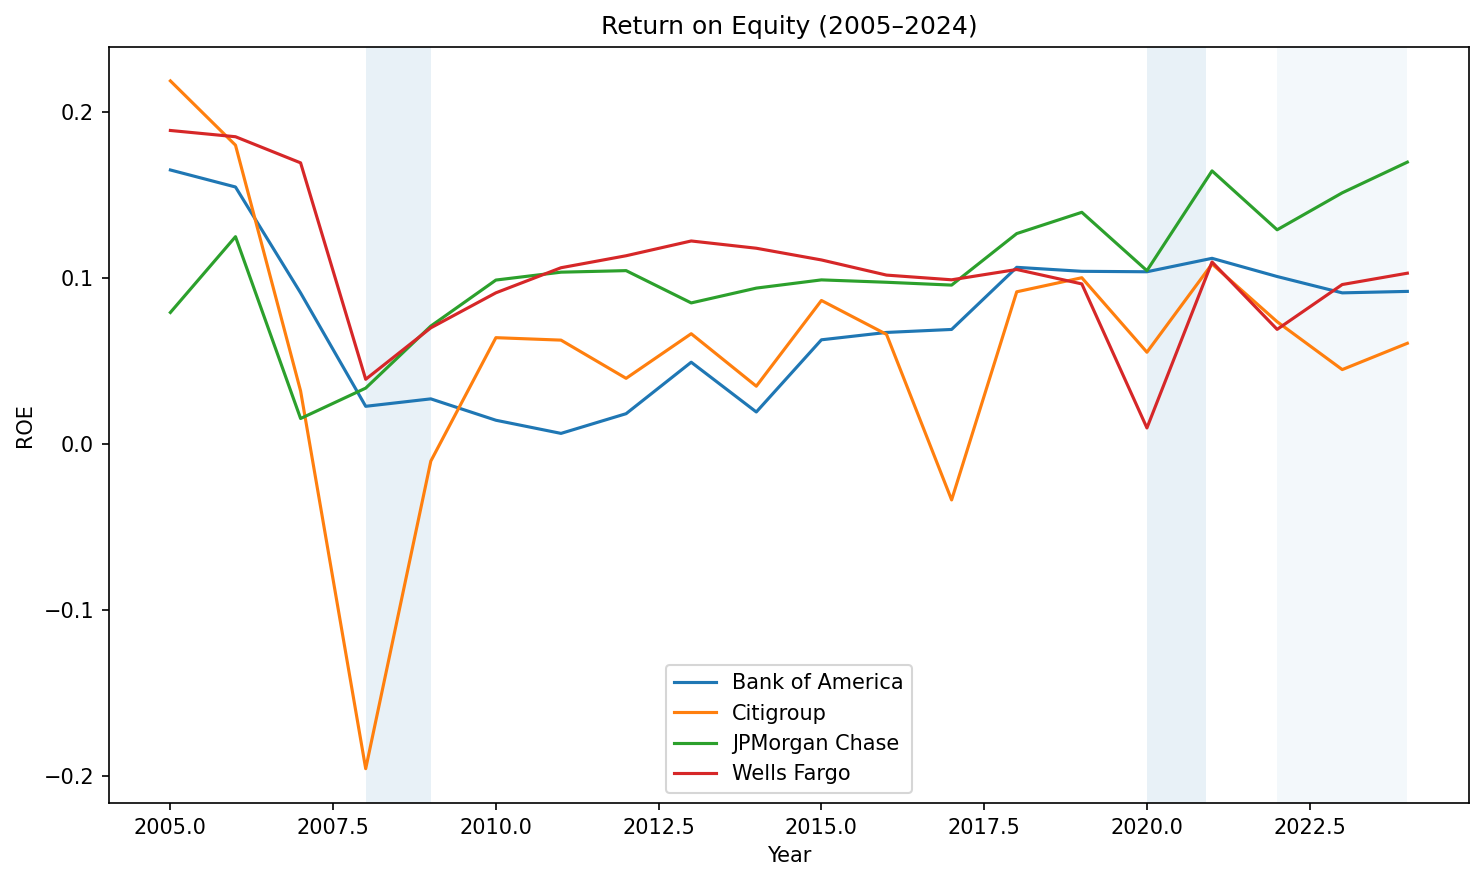

In [2]:
plt.figure(figsize=(10, 6))

for bank, g in combo.groupby("Bank"):

    g = g.sort_values("Year")

    plt.plot(g["Year"], g["ROE"], label=bank)

plt.xlabel("Year")
plt.ylabel("ROE")

plt.title("Return on Equity (2005–2024)")

plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()

plt.show()

**INTERPRETATION:**

This chart compares annual net income relative to equity. Negative ROE identifies loss-making observations, while higher positive values indicate greater earnings relative to the equity denominator. ROE should be read alongside ROA and equity-to-assets because leverage can affect the result.

**RETURN ON ASSETS:**

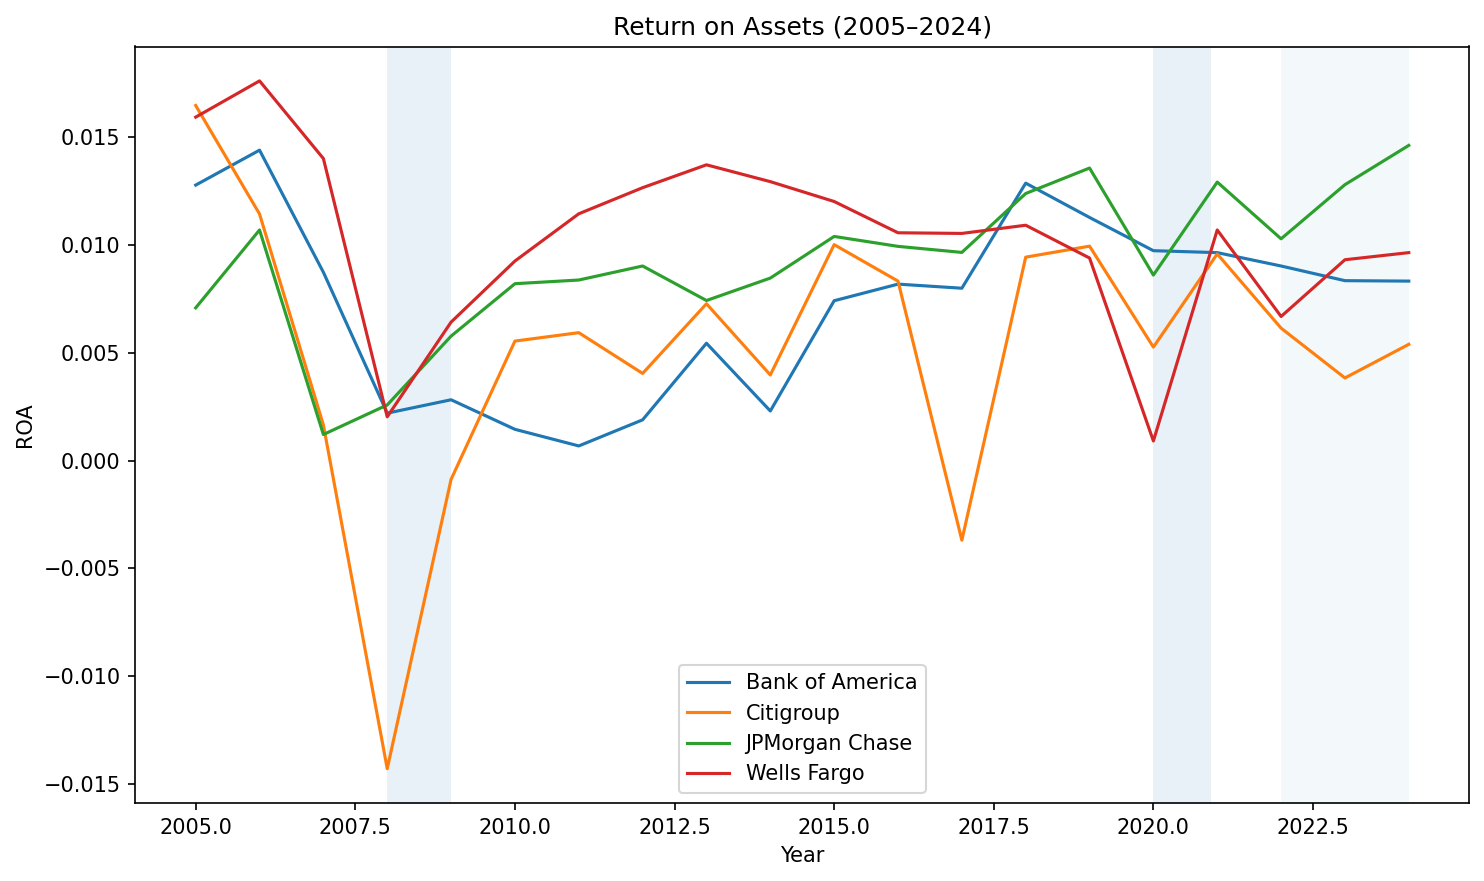

In [3]:
plt.figure(figsize=(10, 6))
for bank, g in combo.groupby("Bank"):
    g = g.sort_values("Year")
    plt.plot(g["Year"], g["ROA"], label=bank)

plt.xlabel("Year")
plt.ylabel("ROA")
plt.title("Return on Assets (2005–2024)")
plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()
plt.show()

**INTERPRETATION:**

This chart compares earnings relative to assets. It provides a size-adjusted view of profitability alongside ROE. Differences between the two charts can help frame questions about financing and balance-sheet composition; they do not by themselves explain the causes.

**PROFIT MARGIN:**

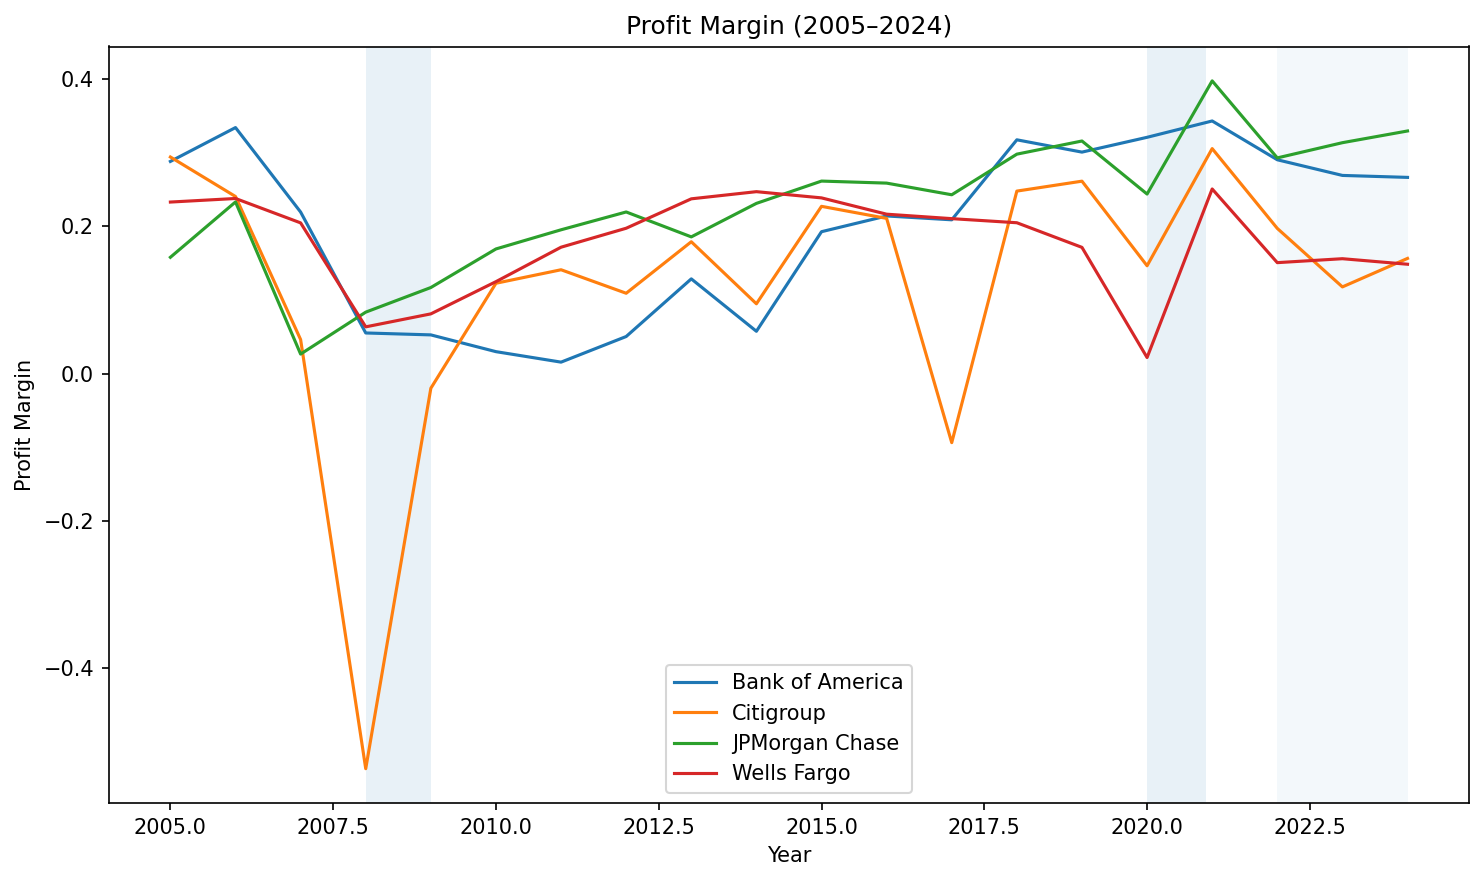

In [4]:
plt.figure(figsize=(10, 6))
for bank, g in combo.groupby("Bank"):
    g = g.sort_values("Year")

    if "Profit Margin" in g.columns:
        plt.plot(g["Year"], g["Profit Margin"], label=bank)

plt.xlabel("Year")
plt.ylabel("Profit Margin")
plt.title("Profit Margin (2005–2024)")
plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()
plt.show()

**INTERPRETATION:**

This chart shows the share of reported revenue represented by net income. A negative margin indicates a net loss despite reported revenue. Cross-bank comparisons depend on whether revenue has been defined consistently, so a higher line is not sufficient evidence of superior operating performance.

**ASSET TURNOVER:**

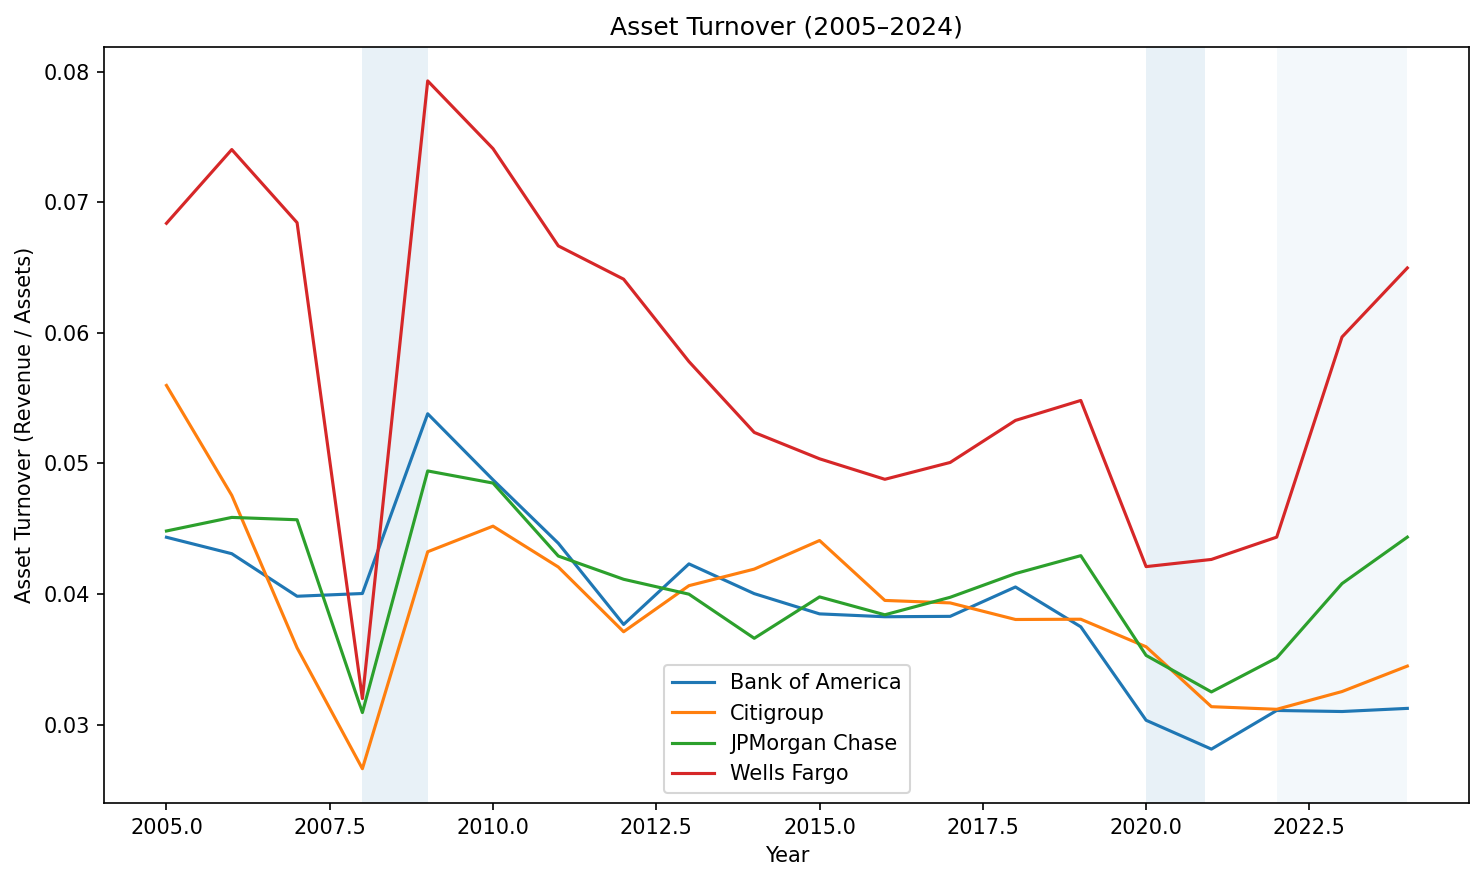

In [5]:
plt.figure(figsize=(10, 6))
for bank, g in combo.groupby("Bank"):
    g = g.sort_values("Year")
    if "Asset Turnover" in g.columns:
        plt.plot(g["Year"], g["Asset Turnover"], label=bank)

plt.xlabel("Year")
plt.ylabel("Asset Turnover (Revenue / Assets)")
plt.title("Asset Turnover (2005–2024)")
plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()
plt.show()

**INTERPRETATION:**

This chart compares reported revenue relative to assets. It adds context about revenue generation, but bank business models and interest-rate conditions can affect the ratio. Higher asset turnover does not necessarily imply higher profitability or lower risk.

**EQUITY-TO-ASSETS RATIO:**

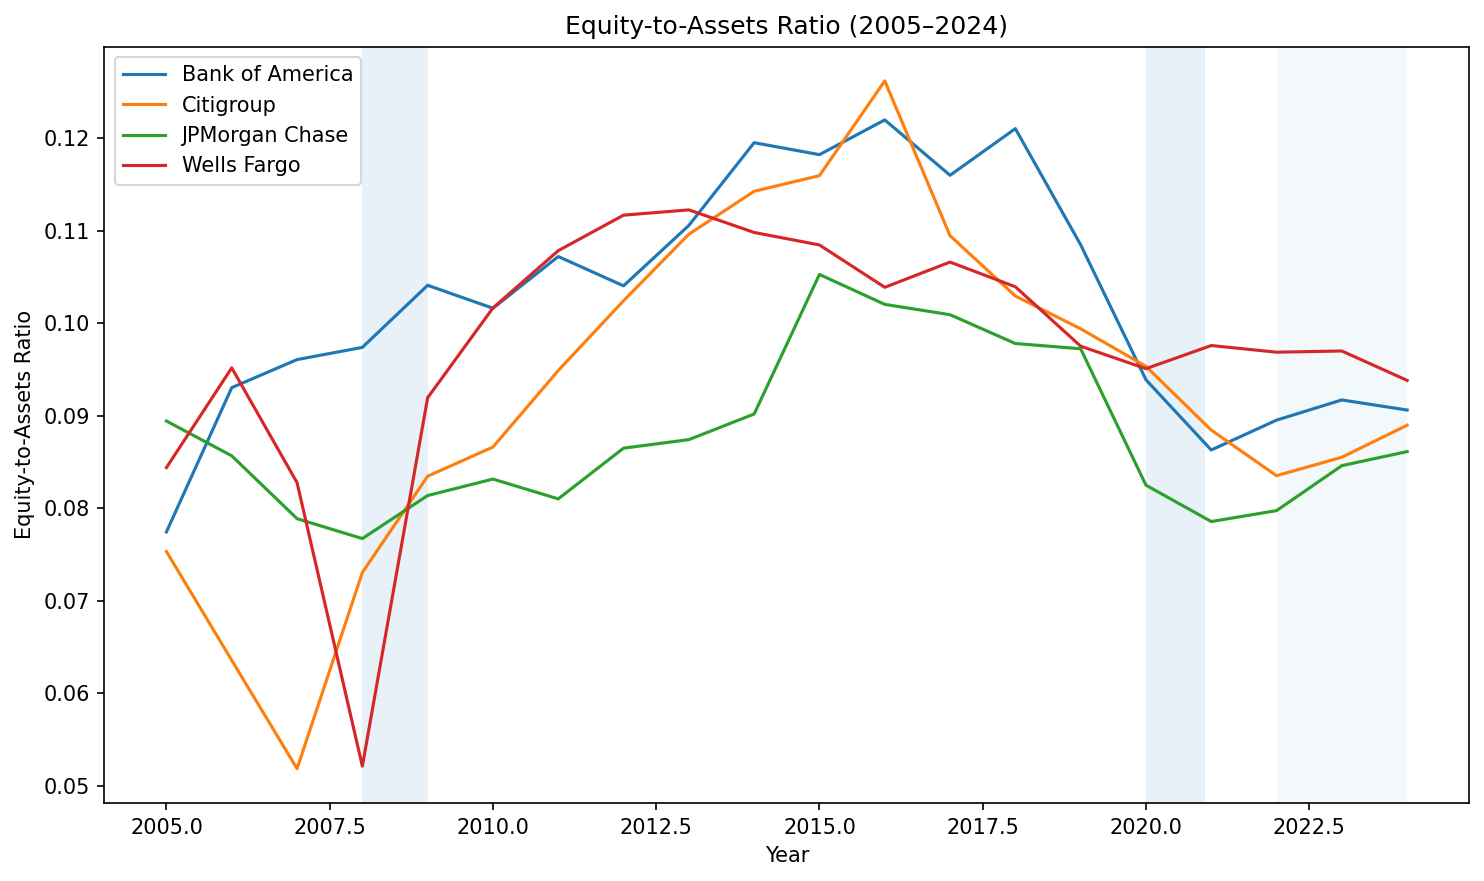

In [6]:
plt.figure(figsize=(10, 6))
for bank, g in combo.groupby("Bank"):
    g = g.sort_values("Year")
    if "Equity_to_Assets" in g.columns:
        plt.plot(g["Year"], g["Equity_to_Assets"], label=bank)

plt.xlabel("Year")
plt.ylabel("Equity-to-Assets Ratio")
plt.title("Equity-to-Assets Ratio (2005–2024)")
plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()
plt.show()

**INTERPRETATION:**

This chart shows shareholder equity relative to assets. A higher ratio generally represents more equity financing relative to the asset base, but it does not capture asset risk or regulatory capital requirements. I use it as financing context rather than a standalone measure of safety.

**TOTAL REVENUE:**

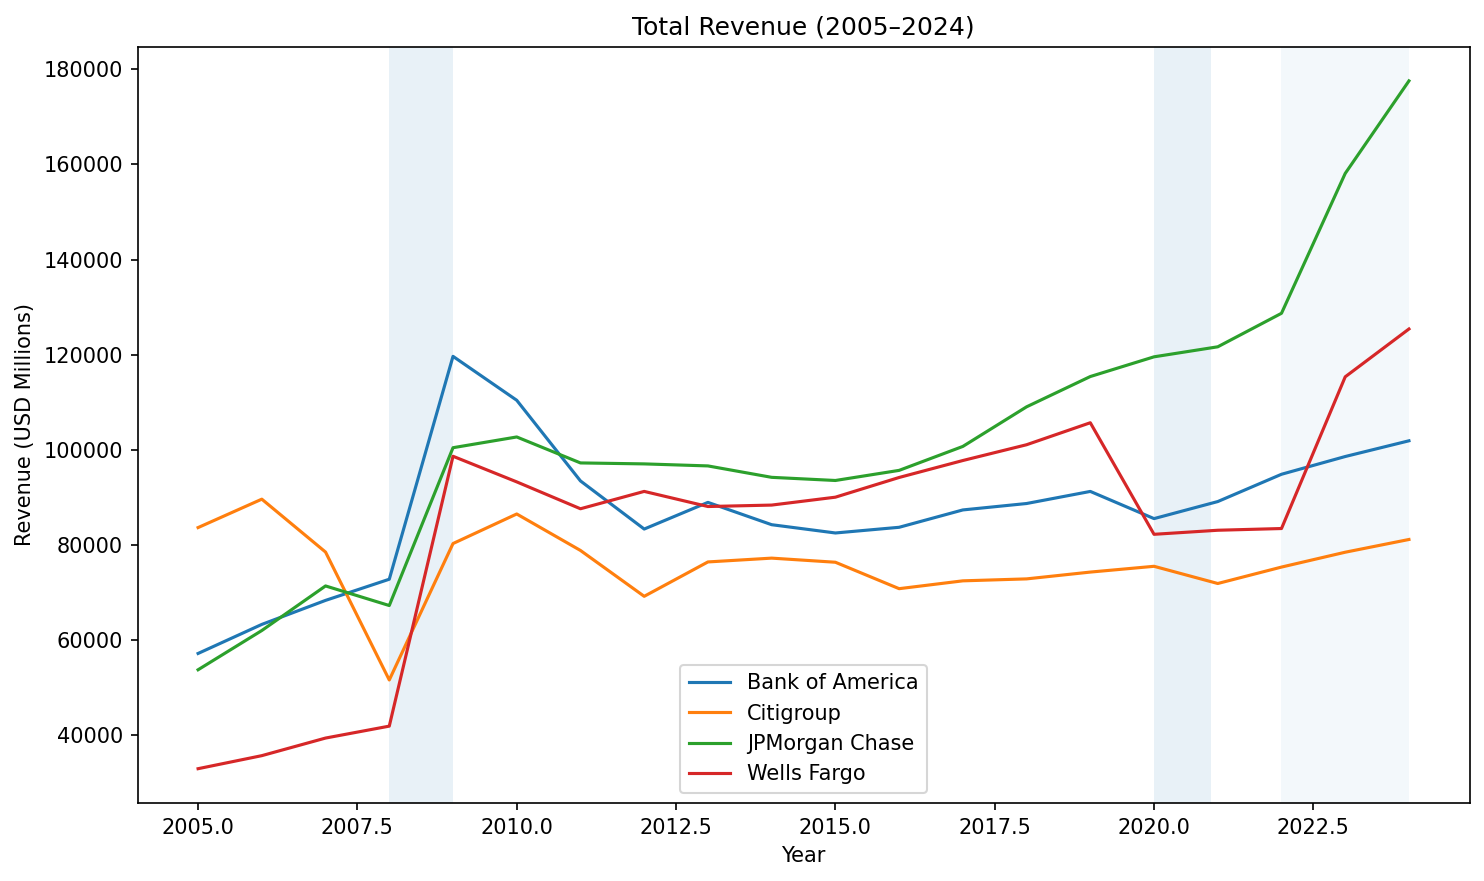

In [7]:
plt.figure(figsize=(10, 6))
for bank, g in combo.groupby("Bank"):
    g = g.sort_values("Year")

    plt.plot(g["Year"], g["Total Revenue"], label=bank)

plt.xlabel("Year")
plt.ylabel("Revenue (USD Millions)")
plt.title("Total Revenue (2005–2024)")
plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()
plt.show()

**INTERPRETATION:**

This chart compares the scale and movement of reported revenue. It should be read together with the ratio charts because larger revenue totals can reflect a larger business rather than stronger efficiency. Revenue definitions must be checked before drawing firm conclusions about differences between banks.

**NET INCOME:**

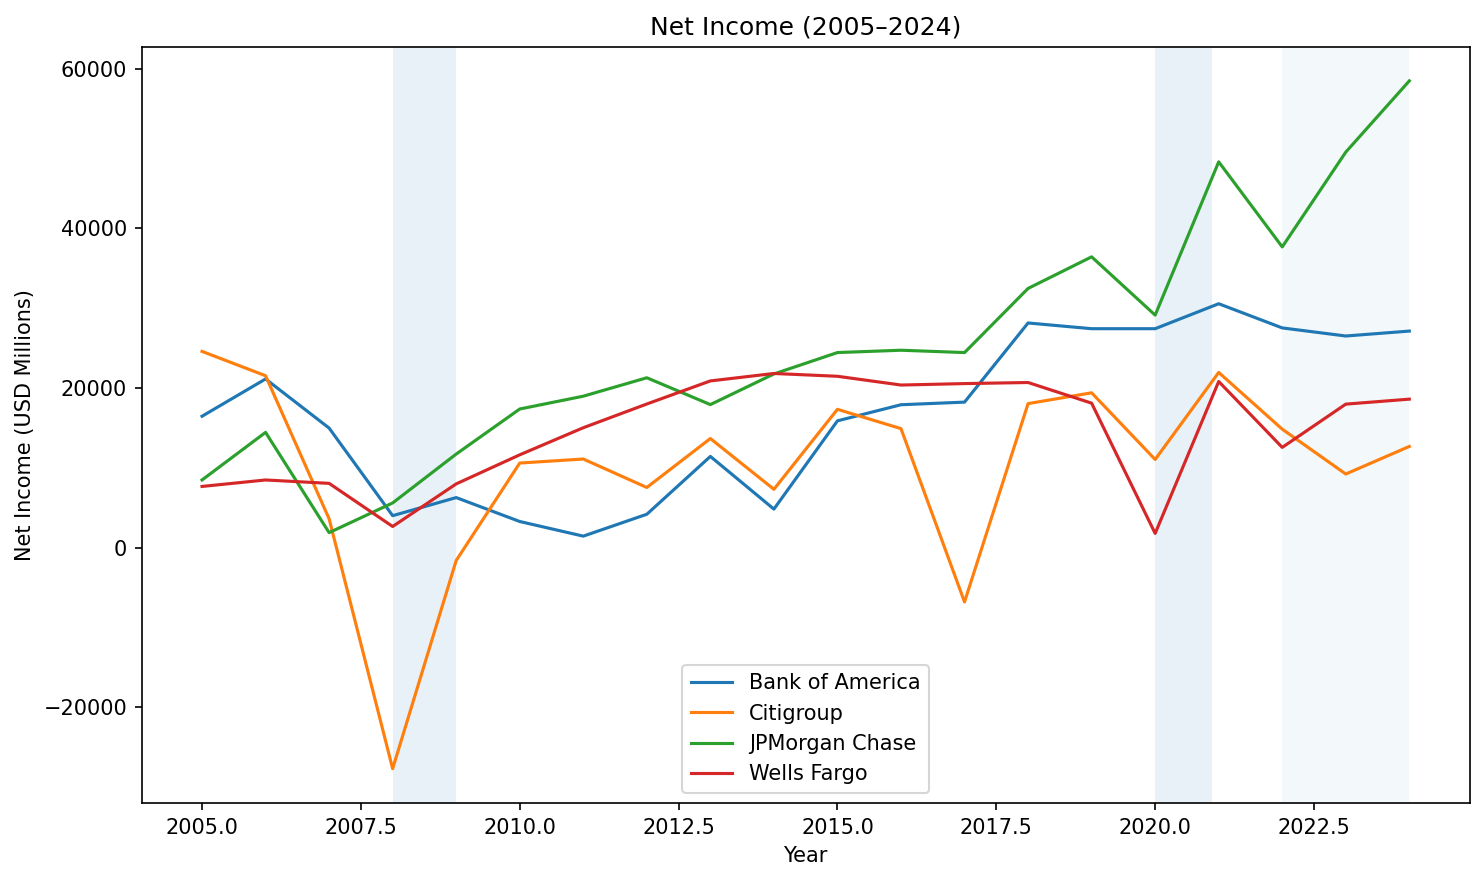

In [8]:
plt.figure(figsize=(10, 6))
for bank, g in combo.groupby("Bank"):
    g = g.sort_values("Year")
    plt.plot(g["Year"], g["Net Income"], label=bank)

plt.xlabel("Year")
plt.ylabel("Net Income (USD Millions)")
plt.title("Net Income (2005–2024)")
plt.legend()

plt.axvspan(2008, 2009, alpha=0.1)
plt.axvspan(2020, 2020.9, alpha=0.1)
plt.axvspan(2022, 2024, alpha=0.05)

plt.tight_layout()
plt.show()

**INTERPRETATION:**

This chart compares annual net earnings in absolute terms. It complements ROA and ROE by showing the size of profits and losses. Differences in bank size mean that a larger profit does not automatically imply better returns on assets or equity.

**EVALUATING THE MODELS:**

Because this project is descriptive, model accuracy and prediction scores do not apply. I evaluate the presentation by checking that the banks are identified, years are ordered, measures have labels, and several complementary indicators are included.

A fuller evaluation would reconcile the original filings, confirm units and definitions, and investigate missing values or unusual movements. The charts support exploration, not a validated risk classification or forecast.

**STORYTELLING:**

The central idea is that financial performance has several dimensions. Revenue and net income show scale, ROA and ROE show profitability relative to the balance sheet, and the other ratios add context about revenue conversion and equity financing.

For Bank of America, viewing these measures alongside three peers helps frame more specific questions: Do changes appear across the industry or mainly at one bank? Are higher profits accompanied by stronger ratios? Do shifts occur near the highlighted economic periods? The charts make these comparisons visible without assuming that timing proves causation.

**IMPACT:**

Presenting financial data clearly can help readers understand the differences between bank size, profitability, and financing. It also demonstrates the value of consolidating historical data into a consistent structure before making comparisons.

These charts should not be used alone to label a bank as safe or risky or to make investment decisions. Differences in accounting and business models, as well as the limited annual sample, can change how the results should be interpreted.

**REFERENCES:**

U.S. Securities and Exchange Commission. (n.d.). Search filings (EDGAR database). U.S. Securities and Exchange Commission. Retrieved September 29, 2025, from https://www.sec.gov/search-filings

Franck, T. (2022, December 27). How Bank of America came back from the brink of collapse. CNBC. Retrieved September 29, 2025, from https://www.cnbc.com/2022/12/27/how-bofa-came-back-from-the-brink-of-collapse.html

Peters, R. (2015, June 28). A brief history of Bank of America in crisis. The Motley Fool. Retrieved September 29, 2025, from https://www.fool.com/investing/general/2015/06/28/a-brief-history-of-bank-of-america-in-crisis.aspx